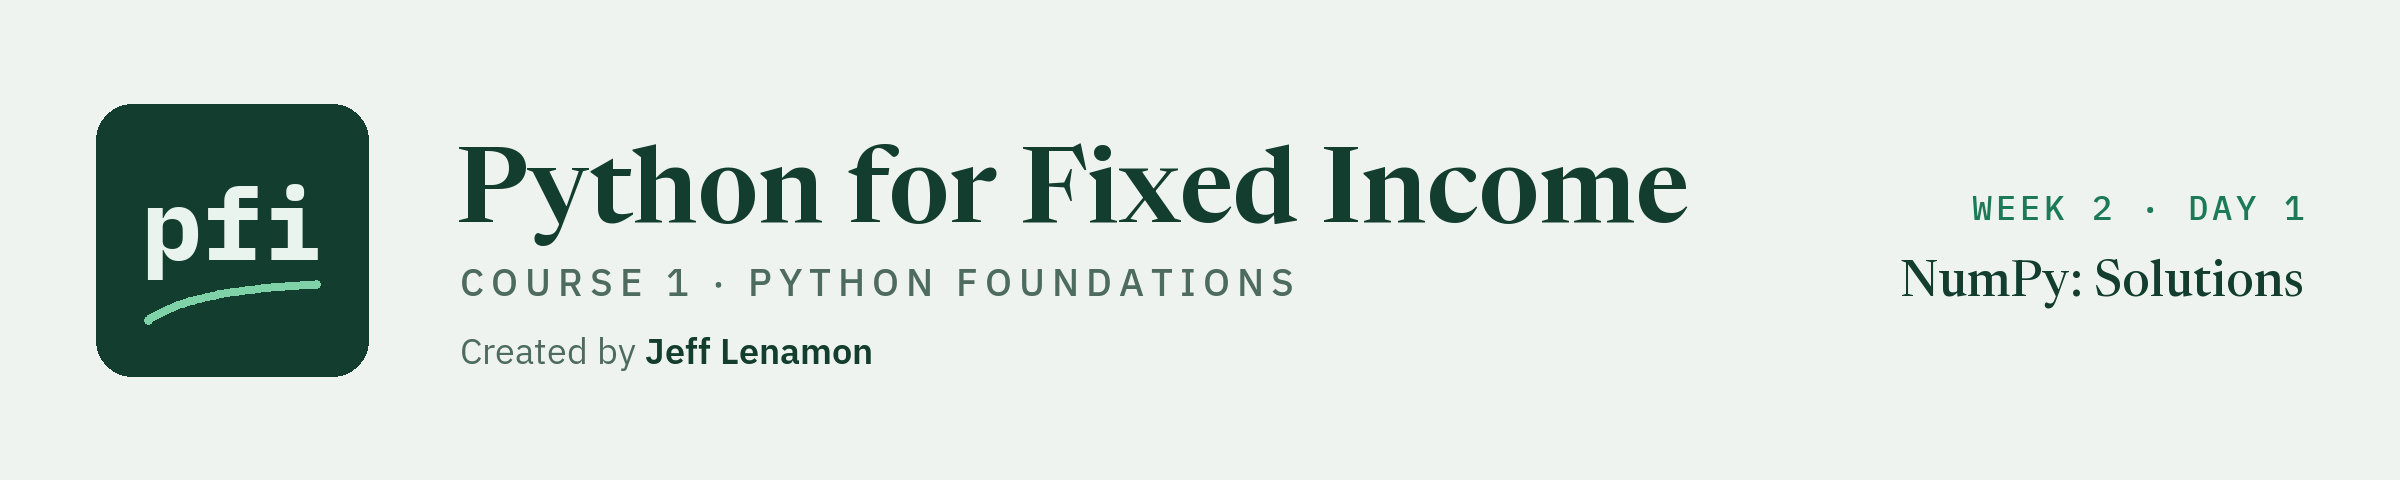

# NumPy - Solutions

Week 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week2/day1/06_numpy_solutions.ipynb)

## Exercises

A second desk holds three different bonds. Use what you learned above to answer its questions. The issuers are invented.

| Ticker | Coupon (%) | Price | Rating | Score | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | 4.375 | 96.25 | A | 6 | 2,000,000 |
| OSMC | 5.00 | 100.00 | BBB- | 10 | 1,250,000 |
| CLDB | 8.25 | 104.50 | B | 15 | 500,000 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports NumPy and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [1]:
import numpy as np


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, np.ndarray) and expected.dtype.kind == 'f':
        # arrays of numbers: same shape, and every value within a small tolerance
        correct = np.shape(answer) == expected.shape and np.allclose(answer, expected)
    elif isinstance(expected, np.ndarray):
        # arrays of text: same shape and the same values
        correct = np.array_equal(answer, expected)
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

### Exercise 1

Q. Create an array for the tickers, coupons, prices, face held, and rating scores of the three bonds. Then work out the cost of every position in one line, and the total cost. Store the answers in **ex1_costs** and **ex1_total_cost**.

In [2]:
# one array per column, all in the same bond order
tickers = np.array(['TRNW', 'OSMC', 'CLDB'])
coupons = np.array([4.375, 5.0, 8.25])
prices = np.array([96.25, 100.0, 104.5])
faces = np.array([2000000, 1250000, 500000])
scores = np.array([6, 10, 15])

# the price is per 100 face, so divide by 100
ex1_costs = faces * prices / 100
# sum() adds up every value in the array
ex1_total_cost = ex1_costs.sum()

print('Costs:', ex1_costs)
print('Total cost:', ex1_total_cost)

Costs: [1925000. 1250000.  522500.]
Total cost: 3697500.0


* 1,925,000, 1,250,000, and 522,500, for a total of 3,697,500. The total matches the one this desk reached with a loop in week 1.

In [3]:
check('Exercise 1 costs', ex1_costs, np.array([1925000.0, 1250000.0, 522500.0]))
check('Exercise 1 total cost', ex1_total_cost, 3697500.0)

Exercise 1 costs: correct
Exercise 1 total cost: correct


### Exercise 2

Q. Work out the current yield of every bond, rounded to two decimal places. Find the ticker of the bond with the highest current yield using `np.argmax()`. Then find the face-weighted average coupon. Store the answers in **ex2_current_yields**, **ex2_highest_ticker**, and **ex2_weighted_coupon**.

In [4]:
# coupon divided by price, in percent, rounded for display
ex2_current_yields = np.round(coupons / prices * 100, 2)
print('Current yields:', ex2_current_yields)

# argmax() gives the position of the largest value, which looks up the ticker
ex2_highest_ticker = tickers[np.argmax(ex2_current_yields)]
print('Highest current yield:', ex2_highest_ticker)

# each coupon counts in proportion to its face
ex2_weighted_coupon = np.average(coupons, weights=faces)
print('Face-weighted average coupon:', ex2_weighted_coupon)

Current yields: [4.55 5.   7.89]
Highest current yield: CLDB
Face-weighted average coupon: 5.1


* The current yields are 4.55, 5.00, and 7.89 percent, and the highest belongs to CLDB.
* The face-weighted average coupon is 5.1. The simple average of the three coupons is 5.875. The weighted figure is lower because more than half of the face is in TRNW, the lowest coupon.

In [5]:
check('Exercise 2 current yields', ex2_current_yields, np.array([4.55, 5.0, 7.89]))
check('Exercise 2 highest ticker', ex2_highest_ticker, 'CLDB')
check('Exercise 2 weighted coupon', ex2_weighted_coupon, 5.1)

Exercise 2 current yields: correct
Exercise 2 highest ticker: correct
Exercise 2 weighted coupon: correct


### Exercise 3

Q. Use a boolean mask to find the tickers of the bonds priced below par, and the total face held in investment grade bonds (a score of 10 or lower). Then use `np.where()` to label each bond 'Below par' when its price is under 100 and 'Par or above' otherwise. Store the answers in **ex3_below_par**, **ex3_ig_face**, and **ex3_labels**.

In [6]:
# keep the tickers where the price is under 100
ex3_below_par = tickers[prices < 100]
print('Below par:', ex3_below_par)

# keep the face amounts where the score is 10 or lower, then add them up
ex3_ig_face = faces[scores <= 10].sum()
print('Investment grade face:', ex3_ig_face)

# np.where(condition, value if True, value if False)
ex3_labels = np.where(prices < 100, 'Below par', 'Par or above')
print('Labels:', ex3_labels)

Below par: ['TRNW']
Investment grade face: 3250000
Labels: ['Below par' 'Par or above' 'Par or above']


* Only TRNW is below par. OSMC is priced at exactly 100, and `prices < 100` is False for it.
* TRNW and OSMC are investment grade, with 3,250,000 of face between them. The test is `<= 10` so that OSMC, at a score of exactly 10, is included.

In [7]:
check('Exercise 3 below par', ex3_below_par, np.array(['TRNW']))
check('Exercise 3 investment grade face', ex3_ig_face, 3250000)
check('Exercise 3 labels', ex3_labels, np.array(['Below par', 'Par or above', 'Par or above']))

Exercise 3 below par: correct
Exercise 3 investment grade face: correct
Exercise 3 labels: correct


### Exercise 4

The second desk's risk system wants the holdings as one table in a file, not as separate columns.

Q. Build a 2-D array with one row per bond and three columns: coupon, price, and face held. Store it in **ex4_table**. Find the average of each column and store it in **ex4_column_averages**. Then save the table to a file named `second_desk_table.csv` with `np.savetxt()`, using a comma as the delimiter and three decimal places, load it back with `np.loadtxt()`, and store the loaded array in **ex4_loaded**.

In [8]:
# plain numbers instead of scientific notation
np.set_printoptions(suppress=True)

# a list of lists: each inner list is one bond
ex4_table = np.array([[4.375, 96.25, 2000000],
                      [5.0, 100.0, 1250000],
                      [8.25, 104.5, 500000]])

# axis=0 works down the rows and gives one result per column
ex4_column_averages = ex4_table.mean(axis=0)
print('Column averages:', ex4_column_averages)

# write the table as text with a comma between the columns
np.savetxt('second_desk_table.csv', ex4_table, delimiter=',', fmt='%.3f')
# read it back. There is no header line, so there are no rows to skip.
ex4_loaded = np.loadtxt('second_desk_table.csv', delimiter=',')
print(ex4_loaded)

Column averages: [      5.875     100.25  1250000.   ]
[[      4.375      96.25  2000000.   ]
 [      5.        100.    1250000.   ]
 [      8.25      104.5    500000.   ]]


* The column averages are 5.875 for the coupon, 100.25 for the price, and 1,250,000 for the face.
* The loaded table matches the original. Three decimal places are enough here because the coupon 4.375 has exactly three.

In [9]:
check('Exercise 4 table', ex4_table, np.array([[4.375, 96.25, 2000000.0], [5.0, 100.0, 1250000.0], [8.25, 104.5, 500000.0]]))
check('Exercise 4 column averages', ex4_column_averages, np.array([5.875, 100.25, 1250000.0]))
check('Exercise 4 loaded', ex4_loaded, np.array([[4.375, 96.25, 2000000.0], [5.0, 100.0, 1250000.0], [8.25, 104.5, 500000.0]]))

Exercise 4 table: correct
Exercise 4 column averages: correct
Exercise 4 loaded: correct


### Exercise 5: AI check

You ask an AI assistant for code that gives the weighted average coupon of the three positions. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Read the code before you run it. What number do you expect? You worked out the face-weighted average coupon yourself in Exercise 2. Then run the code. Does it agree with you?

* The answer from Exercise 2 is 5.1. The original code printed 5.93, with no error.
* The bug was in the weights. The code said `weights=ai_prices`, so each coupon was weighted by the bond's price. The three prices are all close to 100, which makes that nearly a simple average. The weights have to be the face held: `weights=ai_faces`.
* The result looked like a coupon and sat inside the range of the three coupons, so nothing about it stood out. The check that caught it was a number worked out independently.

In [10]:
ai_coupons = np.array([4.375, 5.0, 8.25])
ai_prices = np.array([96.25, 100.0, 104.5])
ai_faces = np.array([2000000, 1250000, 500000])

# weight each coupon by the face held, not by the price
ex5_weighted_coupon = np.average(ai_coupons, weights=ai_faces)
print('The weighted average coupon is', round(ex5_weighted_coupon, 2), 'percent')

The weighted average coupon is 5.1 percent


In [11]:
check('Exercise 5', ex5_weighted_coupon, 5.1)

Exercise 5: correct


When you are finished, run this cell to remove the file that Exercise 4 created.

In [12]:
import os

# remove the file from Exercise 4, if it was created
if os.path.exists('second_desk_table.csv'):
    os.remove('second_desk_table.csv')

print('second_desk_table.csv still there:', os.path.exists('second_desk_table.csv'))

second_desk_table.csv still there: False
